<a href="https://colab.research.google.com/github/PRIYADARSHINI12-tech/Cross-market-Analysis/blob/main/Global_literacy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DATA COLLECTION ADULT LITERACY RATE

In [ ]:
import pandas as pd

df_adult = pd.read_csv("https://ourworldindata.org/grapher/literacy-rate-adults.csv?v=1&csvType=full&useColumnShortNames=true",storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})

df_adult.head()

,entity,code,year,adult_literacy_rate__population_15plus_years__both_sexes__pct__lr_ag15t99
0,Afghanistan,AFG,1979,18.00000
1,Afghanistan,AFG,2011,31.00000
2,Afghanistan,AFG,2015,33.75384
3,Afghanistan,AFG,2021,37.00000
4,Albania,ALB,2001,99.00000


In [ ]:
df_adult.columns = df_adult.columns.str.lower()

df_adult = df_adult.rename(columns={
    'entity': 'Country',
    'code': 'Code',
    'year': 'Year'
})


adult_col = [col for col in df_adult.columns if 'literacy' in col][0]

df_adult = df_adult.rename(columns={
    adult_col: 'Adult_literacy_rate'
})

In [ ]:
df_adult[['Country',"Year"]].drop_duplicates()

,Country,Year
0,Afghanistan,1979
1,Afghanistan,2011
2,Afghanistan,2015
3,Afghanistan,2021
4,Albania,2001
...,...,...
1720,Zambia,2010
1721,Zambia,2018
1722,Zimbabwe,1982
1723,Zimbabwe,1992


In [ ]:
df_adult.head()

,Country,Code,Year,Adult_literacy_rate
0,Afghanistan,AFG,1979,18.00000
1,Afghanistan,AFG,2011,31.00000
2,Afghanistan,AFG,2015,33.75384
3,Afghanistan,AFG,2021,37.00000
4,Albania,ALB,2001,99.00000


YOUTH LITERACY RATE

In [ ]:
import pandas as pd

df_youth = pd.read_csv("https://ourworldindata.org/grapher/literacy-rate-of-young-men-and-women.csv?v=1&csvType=full&useColumnShortNames=true"

,storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})

df_youth.head()

,entity,code,year,youth_literacy_rate__population_15_24_years__male__pct__lr_ag15t24_m,youth_literacy_rate__population_15_24_years__female__pct__lr_ag15t24_f,owid_region
0,Afghanistan,AFG,1979,46.00000,11.00000,Asia
1,Afghanistan,AFG,2011,62.00000,32.00000,Asia
2,Afghanistan,AFG,2015,57.73505,25.48416,Asia
3,Afghanistan,AFG,2021,71.00000,42.00000,Asia
4,Afghanistan,AFG,2022,83.40000,44.17171,Asia


In [ ]:
df_youth = df_youth.rename(columns={
    'entity': 'Country',
    'code': 'Code',
    'year': 'Year',
    'owid_region': 'Region'
})

#  male & female columns
male_col = [col for col in df_youth.columns if 'male' in col][0]
female_col = [col for col in df_youth.columns if 'female' in col][0]


df_youth = df_youth.rename(columns={
    male_col: 'Male_literacy_rate',
    female_col: 'Female_literacy_rate'
})

df_youth = df_youth[
    ['Country', 'Code', 'Year',
     'Male_literacy_rate', 'Female_literacy_rate','Region']
]


print(df_youth.head())



       Country Code  Year  Male_literacy_rate  Female_literacy_rate Region
0  Afghanistan  AFG  1979            46.00000              11.00000   Asia
1  Afghanistan  AFG  2011            62.00000              32.00000   Asia
2  Afghanistan  AFG  2015            57.73505              25.48416   Asia
3  Afghanistan  AFG  2021            71.00000              42.00000   Asia
4  Afghanistan  AFG  2022            83.40000              44.17171   Asia


In [ ]:
df_youth = df_youth.sort_values(by=['Country', 'Year'])

df_youth['Literacy_Gender_Gap'] = df_youth['Male_literacy_rate'] - df_youth['Female_literacy_rate']

df_youth['Youth_Literacy_Average'] = (
    df_youth['Male_literacy_rate'] + df_youth['Female_literacy_rate']
) / 2

df_youth['Literacy_Growth_Rate'] = df_youth.groupby('Country')['Youth_Literacy_Average'].pct_change(fill_method=None) * 100

In [ ]:
df_youth.head()

,Country,Code,Year,Male_literacy_rate,Female_literacy_rate,Region,Literacy_Gender_Gap,Youth_Literacy_Average,Literacy_Growth_Rate
0,Afghanistan,AFG,1979,46.00000,11.00000,Asia,35.00000,28.500000,NaN
1,Afghanistan,AFG,2011,62.00000,32.00000,Asia,30.00000,47.000000,64.912281
2,Afghanistan,AFG,2015,57.73505,25.48416,Asia,32.25089,41.609605,-11.468926
3,Afghanistan,AFG,2021,71.00000,42.00000,Asia,29.00000,56.500000,35.785956
4,Afghanistan,AFG,2022,83.40000,44.17171,Asia,39.22829,63.785855,12.895319


In [ ]:
df_adult = df_adult.sort_values(by=['Country', 'Year'])

In [ ]:
df_literacy = pd.merge(
    df_adult,
    df_youth,
    on=['Country', 'Year'],
    how='inner'
)

In [ ]:
df_literacy.head()

,Country,Code_x,Year,Adult_literacy_rate,Code_y,Male_literacy_rate,Female_literacy_rate,Region,Literacy_Gender_Gap,Youth_Literacy_Average,Literacy_Growth_Rate
0,Afghanistan,AFG,1979,18.00000,AFG,46.00000,11.00000,Asia,35.00000,28.500000,NaN
1,Afghanistan,AFG,2011,31.00000,AFG,62.00000,32.00000,Asia,30.00000,47.000000,64.912281
2,Afghanistan,AFG,2015,33.75384,AFG,57.73505,25.48416,Asia,32.25089,41.609605,-11.468926
3,Afghanistan,AFG,2021,37.00000,AFG,71.00000,42.00000,Asia,29.00000,56.500000,35.785956
4,Albania,ALB,2001,99.00000,ALB,99.00000,99.00000,Europe,0.00000,99.000000,NaN


In [ ]:
df_literacy = df_literacy.drop(columns=['Code_y'])
df_literacy = df_literacy.rename(columns={'Code_x': 'Code'})

In [ ]:
df_literacy['Education_Index'] = (
    df_literacy['Adult_literacy_rate'] + df_literacy['Youth_Literacy_Average']
) / 2

In [ ]:
df_literacy = df_literacy.sort_values(by=['Country', 'Year'])

df_literacy['Overall_Literacy_Growth'] = (
    df_literacy.groupby('Country')['Literacy_Growth_Rate']
    .pct_change(fill_method=None) * 100
)

In [ ]:
df_literacy.head()

,Country,Code,Year,Adult_literacy_rate,Male_literacy_rate,Female_literacy_rate,Region,Literacy_Gender_Gap,Youth_Literacy_Average,Literacy_Growth_Rate,Education_Index,Overall_Literacy_Growth
0,Afghanistan,AFG,1979,18.00000,46.00000,11.00000,Asia,35.00000,28.500000,NaN,23.250000,NaN
1,Afghanistan,AFG,2011,31.00000,62.00000,32.00000,Asia,30.00000,47.000000,64.912281,39.000000,NaN
2,Afghanistan,AFG,2015,33.75384,57.73505,25.48416,Asia,32.25089,41.609605,-11.468926,37.681722,-117.668345
3,Afghanistan,AFG,2021,37.00000,71.00000,42.00000,Asia,29.00000,56.500000,35.785956,46.750000,-412.025360
4,Albania,ALB,2001,99.00000,99.00000,99.00000,Europe,0.00000,99.000000,NaN,99.000000,NaN


In [ ]:
df_literacy.to_csv('literacy.csv', index=False)

ILLITERACY

In [ ]:
import pandas as pd

df_illiteracy = pd.read_csv("https://ourworldindata.org/grapher/literate-and-illiterate-world-population.csv?v=1&csvType=full&useColumnShortNames=true"

,storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})

df_illiteracy.head()

,entity,code,year,illiteracy_rate,literacy_rate
0,Afghanistan,AFG,1950,97.000000,3.00000
1,Afghanistan,AFG,1979,82.000000,18.00000
2,Afghanistan,AFG,2011,69.000000,31.00000
3,Afghanistan,AFG,2015,66.246155,33.75384
4,Afghanistan,AFG,2021,63.000000,37.00000


In [ ]:
df_illiteracy = df_illiteracy.rename(columns={
    "entity": "Country",
    "code": "Code",
    "year": "Year",
    "illiteracy_rate": "Illiteracy_rate",
    "literacy_rate": "Literacy_rate"
})

In [ ]:
df_illiteracy["Illiteracy_Percentage"] = 100 - df_illiteracy["Literacy_rate"]

In [ ]:
df_illiteracy = df_illiteracy.sort_values(by=['Country', 'Year'])

In [ ]:
df_illiteracy.head()

,Country,Code,Year,Illiteracy_rate,Literacy_rate,Illiteracy_Percentage
0,Afghanistan,AFG,1950,97.000000,3.00000,97.00000
1,Afghanistan,AFG,1979,82.000000,18.00000,82.00000
2,Afghanistan,AFG,2011,69.000000,31.00000,69.00000
3,Afghanistan,AFG,2015,66.246155,33.75384,66.24616
4,Afghanistan,AFG,2021,63.000000,37.00000,63.00000


In [ ]:
df_illiteracy.to_csv("illiteracy.csv", index=False)

GDP SCHOOLING AND AVERAGE YEARS OF SCHOOLING

In [ ]:
import pandas as pd

df_gdp_schooling = pd.read_csv("https://ourworldindata.org/grapher/gdp-per-capita-worldbank.csv?v=1&csvType=full&useColumnShortNames=true"

,storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})

df_gdp_schooling.head()

,entity,code,year,ny_gdp_pcap_pp_kd,owid_region
0,Afghanistan,AFG,2000,1617.8264,Asia
1,Afghanistan,AFG,2001,1454.1108,Asia
2,Afghanistan,AFG,2002,1774.3087,Asia
3,Afghanistan,AFG,2003,1815.9282,Asia
4,Afghanistan,AFG,2004,1776.9182,Asia


In [ ]:
df_gdp_schooling = df_gdp_schooling.rename(columns={
    "entity": "Country",
    "code": "Code",
    "year": "Year",
    "ny_gdp_pcap_pp_kd": "GDP",
    "owid_region": "Region"
})

In [ ]:
df_gdp_schooling.head()

,Country,Code,Year,GDP,Region
0,Afghanistan,AFG,2000,1617.8264,Asia
1,Afghanistan,AFG,2001,1454.1108,Asia
2,Afghanistan,AFG,2002,1774.3087,Asia
3,Afghanistan,AFG,2003,1815.9282,Asia
4,Afghanistan,AFG,2004,1776.9182,Asia


In [ ]:
import pandas as pd

df_schooling = pd.read_csv("https://ourworldindata.org/grapher/literacy-rates-vs-average-years-of-schooling.csv?v=1&csvType=full&useColumnShortNames=true"

,storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})

df_schooling.head()

,entity,code,year,literacy_rate,mf_youth_and_adults__15_64_years__average_years_of_education,population_historical,owid_region
0,Afghanistan,AFG,1870,NaN,0.01,4101170.0,Asia
1,Afghanistan,AFG,1875,NaN,0.01,4193635.0,Asia
2,Afghanistan,AFG,1880,NaN,0.01,4288021.0,Asia
3,Afghanistan,AFG,1885,NaN,0.01,4384343.0,Asia
4,Afghanistan,AFG,1890,NaN,0.01,4482635.0,Asia


In [ ]:
df_schooling = df_schooling.rename(columns={
    "entity": "Country",
    "code": "Code",
    "year": "Year",
    "literacy_rate": "Literacy_rate",
    "mf_youth_and_adults__15_64_years__average_years_of_education": "Avg_years_of_schooling",
    "population_historical": "Population",
    "owid_region": "Region"
})

In [ ]:
df_schooling.head()

,Country,Code,Year,Literacy_rate,Avg_years_of_schooling,Population,Region
0,Afghanistan,AFG,1870,NaN,0.01,4101170.0,Asia
1,Afghanistan,AFG,1875,NaN,0.01,4193635.0,Asia
2,Afghanistan,AFG,1880,NaN,0.01,4288021.0,Asia
3,Afghanistan,AFG,1885,NaN,0.01,4384343.0,Asia
4,Afghanistan,AFG,1890,NaN,0.01,4482635.0,Asia


In [ ]:
df_gdp_schooling = df_gdp_schooling.sort_values(by=['Country', 'Year'])
df_schooling = df_schooling.sort_values(by=['Country', 'Year'])

In [ ]:
df_gdp_edu = df_gdp_schooling.merge(
    df_schooling[['Country', 'Year', 'Avg_years_of_schooling']],
    on=['Country', 'Year'],
    how='inner'
)

In [ ]:
df_gdp_schooling = df_gdp_schooling.sort_values(by=['Country', 'Year'])
df_schooling = df_schooling.sort_values(by=['Country', 'Year'])

In [ ]:
df_gdp_schooling = df_gdp_schooling.merge(
    df_schooling[['Country', 'Year', 'Avg_years_of_schooling']],
    on=['Country', 'Year'],
    how='inner'
)

In [ ]:
df_gdp_schooling.to_csv('df_gdp_schooling.csv', index=False)

In [ ]:
df_schooling.head()

,Country,Code,Year,Literacy_rate,Avg_years_of_schooling,Population,Region
0,Afghanistan,AFG,1870,NaN,0.01,4101170.0,Asia
1,Afghanistan,AFG,1875,NaN,0.01,4193635.0,Asia
2,Afghanistan,AFG,1880,NaN,0.01,4288021.0,Asia
3,Afghanistan,AFG,1885,NaN,0.01,4384343.0,Asia
4,Afghanistan,AFG,1890,NaN,0.01,4482635.0,Asia


In [ ]:
import pandas as pd

# ==============================
# FILTER THE YEARS (1990–2026)
# ==============================

df_adult = df_adult[(df_adult['Year'] >= 1990) & (df_adult['Year'] <= 2026)]
df_youth = df_youth[(df_youth['Year'] >= 1990) & (df_youth['Year'] <= 2026)]
df_illiteracy = df_illiteracy[(df_illiteracy['Year'] >= 1990) & (df_illiteracy['Year'] <= 2026)]
df_gdp_schooling = df_gdp_schooling[(df_gdp_schooling['Year'] >= 1990) & (df_gdp_schooling['Year'] <= 2026)]
df_schooling = df_schooling[(df_schooling['Year'] >= 1990) & (df_schooling['Year'] <= 2026)]

EDA

In [ ]:
df_literacy.head()
df_literacy.info()
df_literacy.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1708 entries, 0 to 1707
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Country                  1708 non-null   object 
 1   Code                     979 non-null    object 
 2   Year                     1708 non-null   int64  
 3   Adult_literacy_rate      1708 non-null   float64
 4   Male_literacy_rate       1708 non-null   float64
 5   Female_literacy_rate     1708 non-null   float64
 6   Region                   931 non-null    object 
 7   Literacy_Gender_Gap      1708 non-null   float64
 8   Youth_Literacy_Average   1708 non-null   float64
 9   Literacy_Growth_Rate     1484 non-null   float64
 10  Education_Index          1708 non-null   float64
 11  Overall_Literacy_Growth  1226 non-null   float64
dtypes: float64(8), int64(1), object(3)
memory usage: 160.3+ KB


/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


,Year,Adult_literacy_rate,Male_literacy_rate,Female_literacy_rate,Literacy_Gender_Gap,Youth_Literacy_Average,Literacy_Growth_Rate,Education_Index,Overall_Literacy_Growth
count,1708.000000,1708.000000,1708.000000,1708.000000,1708.000000,1708.000000,1484.000000,1708.000000,1226.000000
mean,2003.856557,77.337579,89.016848,83.591187,5.425661,86.304018,2.163912,81.820798,NaN
std,13.192679,19.312535,12.667570,19.246105,7.972229,15.797178,8.673751,17.398832,NaN
min,1970.000000,9.000000,22.000000,7.000000,-19.000000,14.500000,-36.500000,11.750000,-inf
25%,1994.000000,64.441170,82.819005,72.948222,0.000000,77.500000,0.000000,70.562186,-100.000000
50%,2007.000000,82.143840,94.000000,92.000000,1.000000,92.708880,0.346785,87.331809,-28.812195
75%,2015.000000,94.000000,98.479942,98.835233,10.164140,98.505364,1.161064,96.250000,9.187821
max,2023.000000,100.000000,100.000000,100.000000,48.000000,100.000000,125.714286,100.000000,inf


In [ ]:
df_literacy.isnull().sum()

,0
Country,0
Code,729
Year,0
Adult_literacy_rate,0
Male_literacy_rate,0
Female_literacy_rate,0
Region,777
Literacy_Gender_Gap,0
Youth_Literacy_Average,0
Literacy_Growth_Rate,224


UNIVARITE DISTRIBUTION
LITERACY DISTRIBUTION

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

#
sns.set()

UNIVARIATE DISTRIBUTION HISTOGRAM

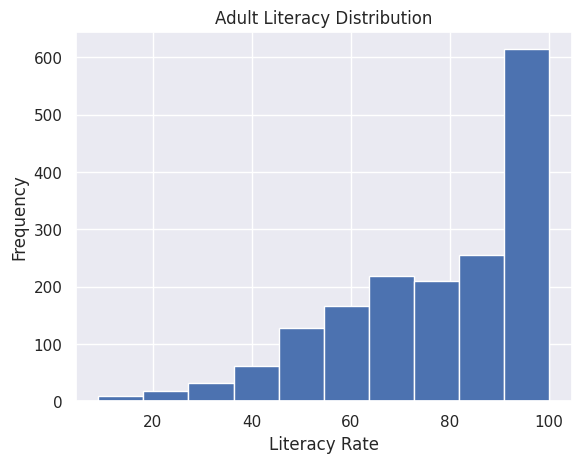

In [ ]:
plt.figure()
df_literacy['Adult_literacy_rate'].hist()
plt.title('Adult Literacy Distribution')
plt.xlabel('Literacy Rate')
plt.ylabel('Frequency')
plt.show()

BOX PLOT (OUTLIERS DETECTION)

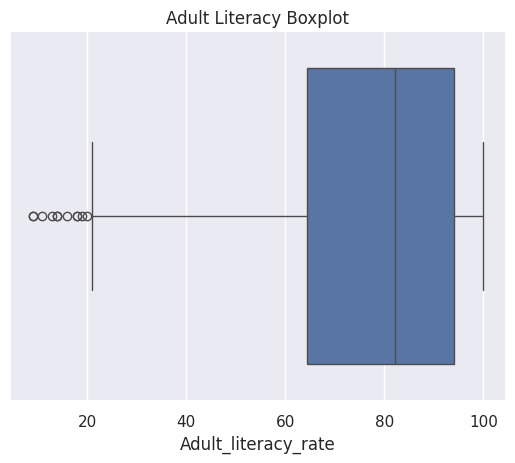

In [ ]:
plt.figure()
sns.boxplot(x=df_literacy['Adult_literacy_rate'])
plt.title('Adult Literacy Boxplot')
plt.show()

GDP DISTRIBUTION

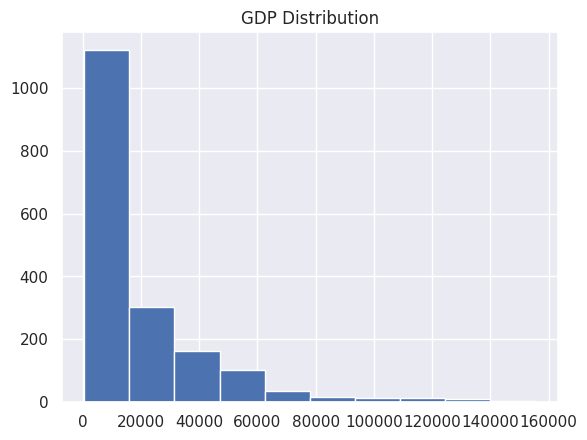

In [ ]:
plt.figure()
df_gdp_schooling['GDP'].hist()
plt.title('GDP Distribution')
plt.show()

SCHOOLING YEARS DISTRIBUTION

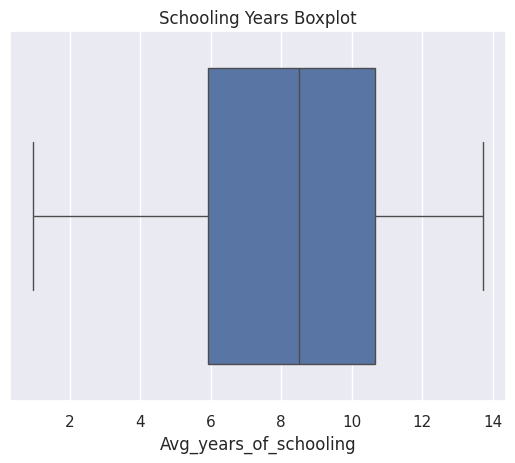

In [ ]:
plt.figure()
sns.boxplot(x=df_gdp_schooling['Avg_years_of_schooling'])
plt.title('Schooling Years Boxplot')
plt.show()

BAR CHART REGION WISE

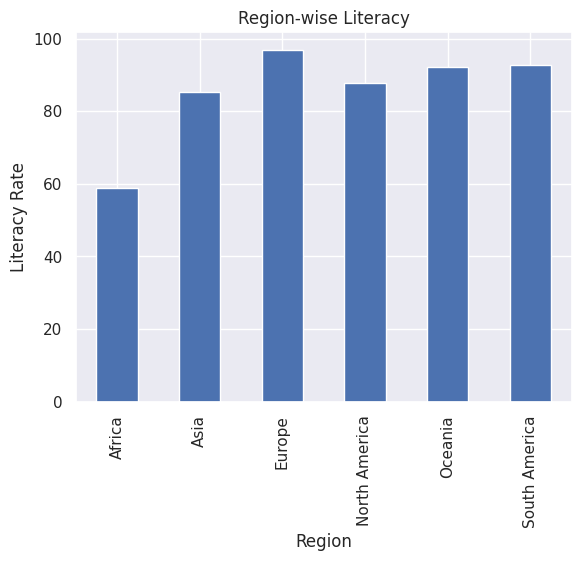

In [ ]:
region_lit = df_literacy.groupby('Region')['Adult_literacy_rate'].mean()

region_lit.plot(kind='bar')
plt.title('Region-wise Literacy')
plt.ylabel('Literacy Rate')
plt.show()

2.BIVARIATE ANALYSIS
SCATTER PLOT(GDP VS LITERACY)

In [ ]:
df_literacygdp = pd.merge(df_literacy, df_gdp_schooling,
                     on=['Country', 'Year'], how='inner')

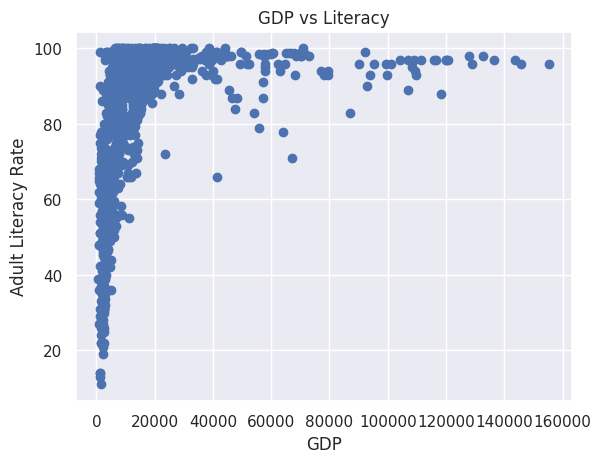

In [ ]:
plt.figure()

plt.scatter(df_literacygdp['GDP'], df_literacygdp['Adult_literacy_rate'])

plt.xlabel('GDP')
plt.ylabel('Adult Literacy Rate')
plt.title('GDP vs Literacy')

plt.show()

SCATTER SCHOOLING VS GDP

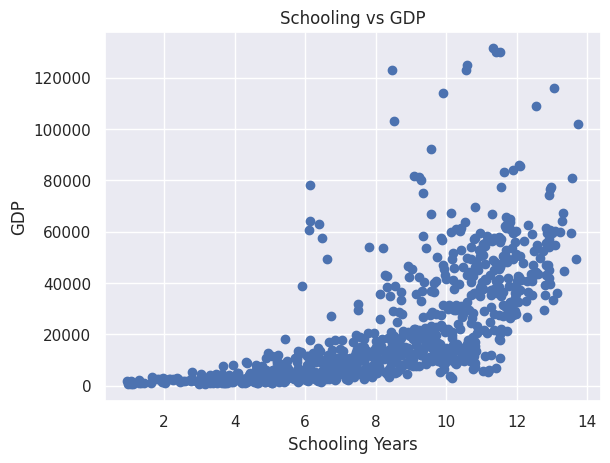

In [ ]:
plt.figure()
plt.scatter(df_gdp_schooling['Avg_years_of_schooling'],
            df_gdp_schooling['GDP'])
plt.xlabel('Schooling Years')
plt.ylabel('GDP')
plt.title('Schooling vs GDP')
plt.show()

GENDER GAP VS LITERACY

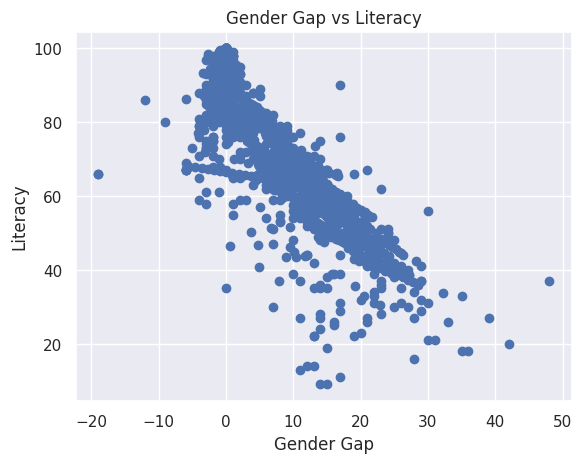

In [ ]:
plt.figure()
plt.scatter(df_literacy['Literacy_Gender_Gap'],
            df_literacy['Adult_literacy_rate'])
plt.xlabel('Gender Gap')
plt.ylabel('Literacy')
plt.title('Gender Gap vs Literacy')
plt.show()

LINE PLOT (TREND OVER TIME)

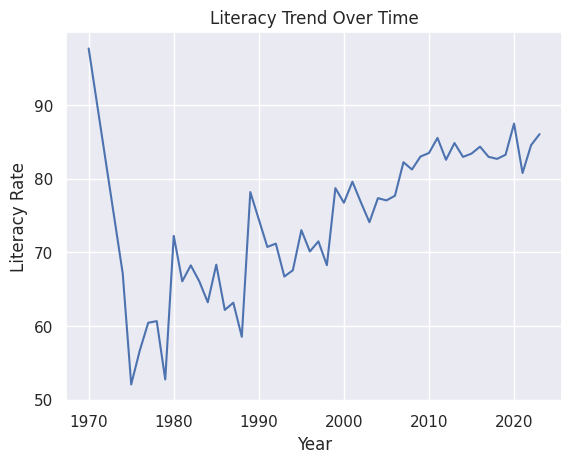

In [ ]:
df_literacy.groupby('Year')['Adult_literacy_rate'].mean().plot()
plt.title('Literacy Trend Over Time')
plt.xlabel('Year')
plt.ylabel('Literacy Rate')
plt.show()

CORRELATION HEATMAP

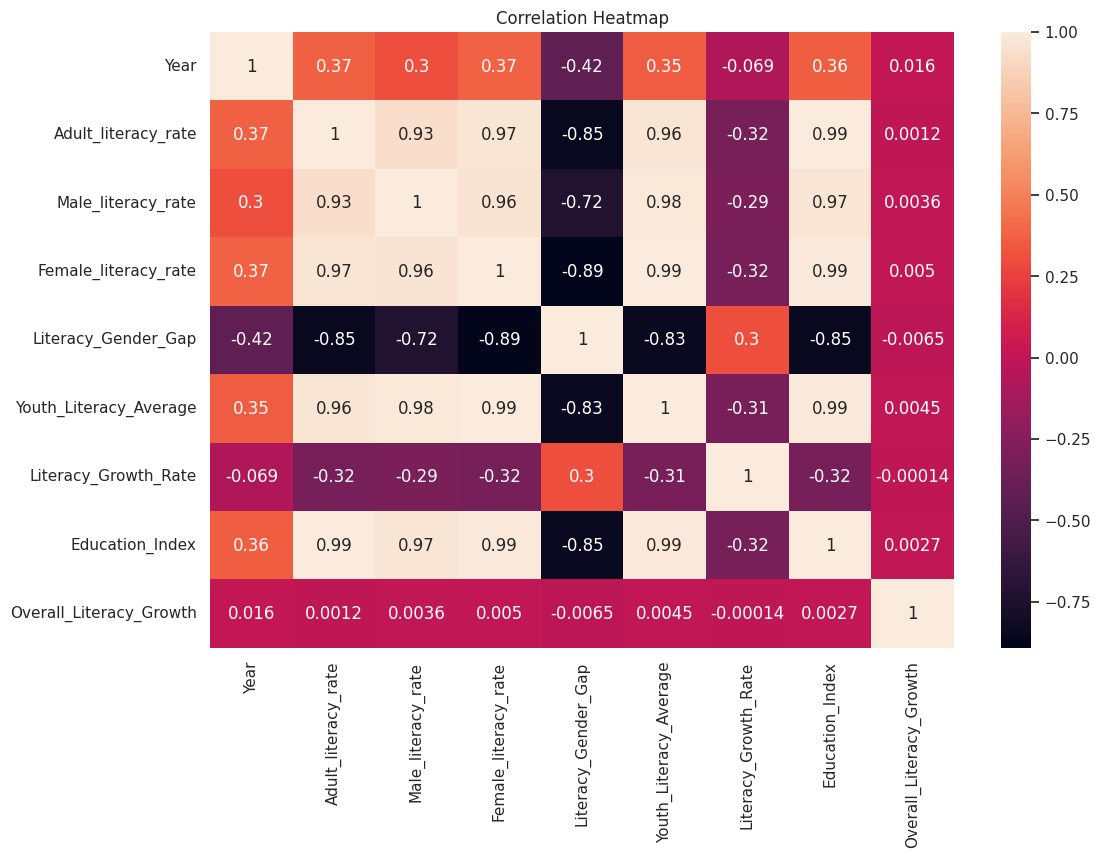

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df_literacy.corr(numeric_only=True), annot=True)
plt.title('Correlation Heatmap')
plt.show()

PLOTLY INTERACTIVE

INTERACTIVE SCATTER

In [ ]:
import plotly.express as px

fig = px.scatter(
    df_literacygdp,
    x='GDP',
    y='Adult_literacy_rate',
    color='Region_x',
    title='GDP vs Literacy (Interactive)'
)

fig.show()

INTERACTIVE LINE POT

OUTLIERS CHECK

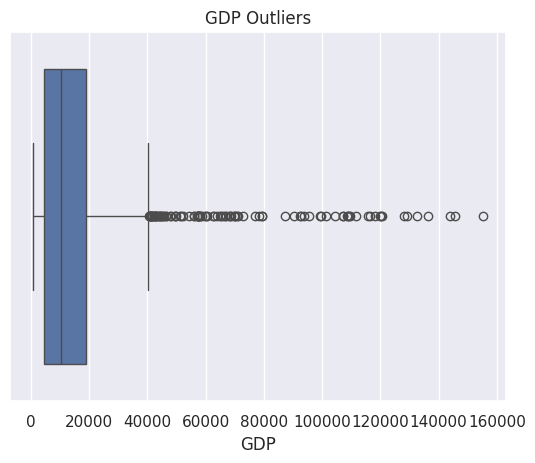

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

In [ ]:
sns.boxplot(x=df_literacygdp['GDP'])
plt.title('GDP Outliers')
plt.show()
#
plt

SUMMARY INSIGHTS

In [ ]:
print("Average Literacy:", df_literacy['Adult_literacy_rate'].mean())
print("Average GDP:", df_literacygdp['GDP'].mean())
print("Average Schooling:", df_gdp_schooling['Avg_years_of_schooling'].mean())

Average Literacy: 77.33757857728337
Average GDP: 16896.166184884147
Average Schooling: 8.194709517923362


In [ ]:
df_final = pd.merge(df_literacy, df_gdp_schooling,
                    on=['Country', 'Year'], how='inner')

df_final = pd.merge(df_final, df_illiteracy,
                    on=['Country', 'Year'], how='inner')

In [ ]:
print(df_final.columns)

Index(['Country', 'Code_x', 'Year', 'Adult_literacy_rate',
       'Male_literacy_rate', 'Female_literacy_rate', 'Region',
       'Literacy_Gender_Gap', 'Youth_Literacy_Average', 'Literacy_Growth_Rate',
       'Education_Index', 'Overall_Literacy_Growth', 'Code_y', 'GDP',
       'Avg_years_of_schooling', 'Code', 'Illiteracy_rate', 'Literacy_rate',
       'Illiteracy_Percentage'],
      dtype='object')


In [ ]:
df_final = df_final.rename(columns={
    'Region_x': 'Region'
})

In [ ]:
df_final = df_final.drop(columns=['Region_y'])


--- Illiteracy Summary ---
count    1079.000000
mean       19.160352
std        19.238772
min         0.000000
25%         4.030971
50%        10.000000
75%        32.380268
max        89.000000
Name: Illiteracy_rate, dtype: float64


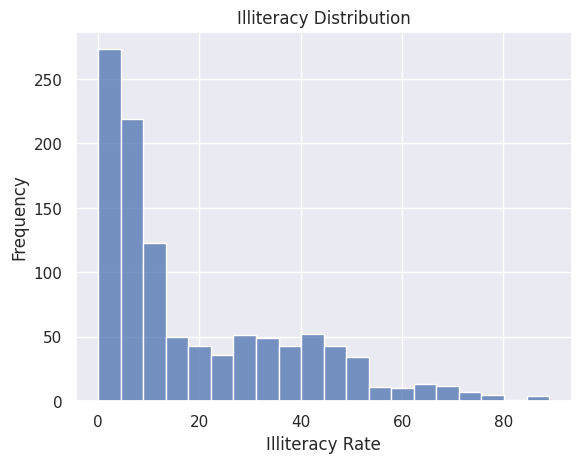

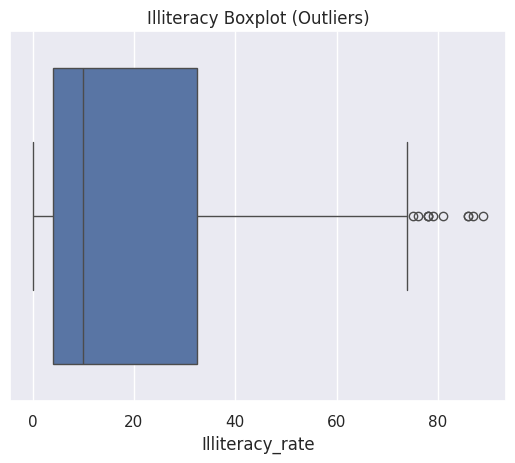

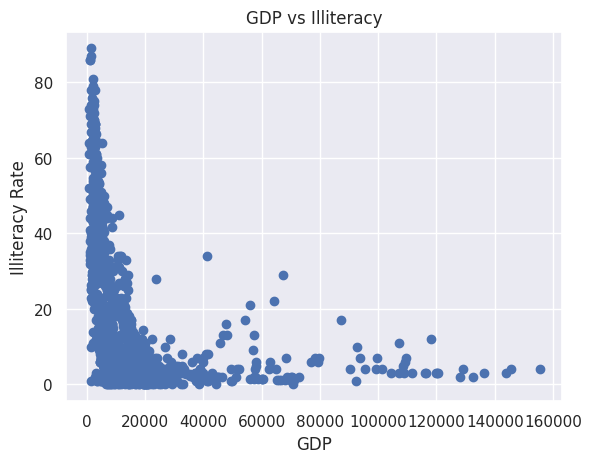

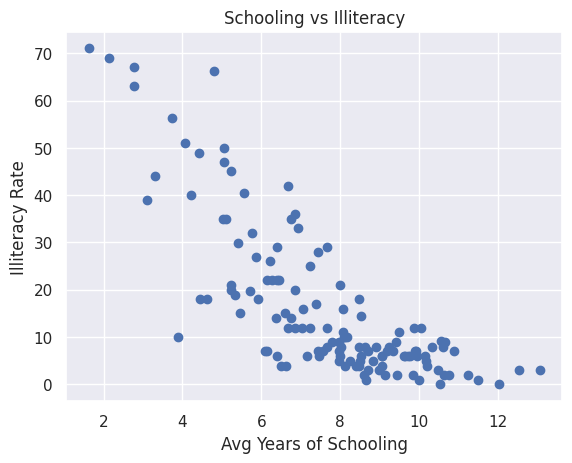

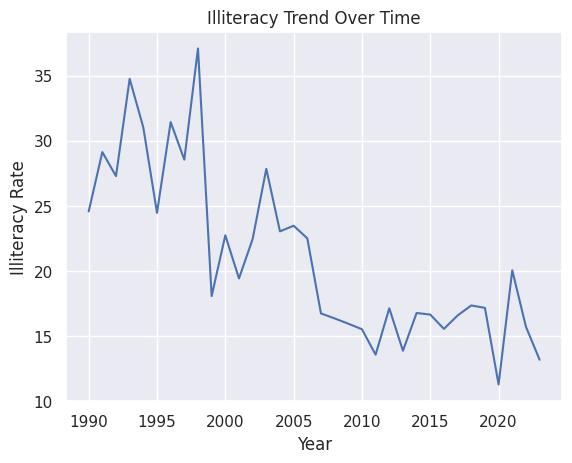

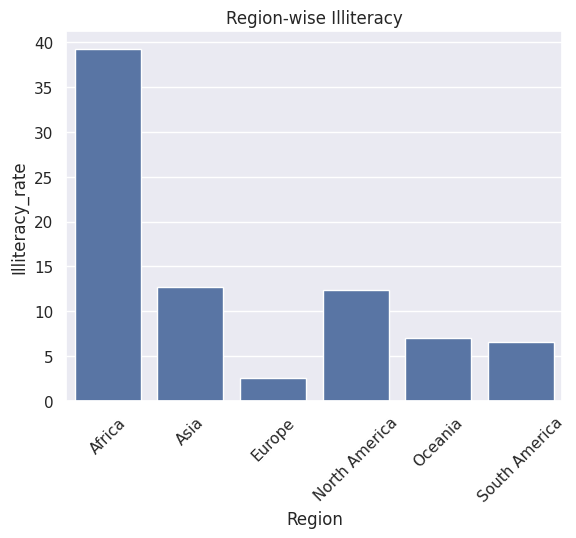


--- Correlation with Illiteracy ---
Illiteracy_rate            1.000000
Illiteracy_Percentage      1.000000
Literacy_Gender_Gap        0.842844
Literacy_Growth_Rate       0.398539
Overall_Literacy_Growth   -0.000267
Year                      -0.213998
GDP                       -0.438332
Avg_years_of_schooling    -0.787113
Male_literacy_rate        -0.945204
Youth_Literacy_Average    -0.962531
Female_literacy_rate      -0.962576
Education_Index           -0.992513
Adult_literacy_rate       -1.000000
Literacy_rate             -1.000000
Name: Illiteracy_rate, dtype: float64



--- FINAL SUMMARY ---
Average Illiteracy: 19.16035154632067
Maximum Illiteracy: 89.0
Minimum Illiteracy: 0.0


In [ ]:
# ==============================
# ✅ IMPORT LIBRARIES
# ==============================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set()


# ==============================
# ==============================
#  UNIVARIATE ANALYSIS
# ==============================

print("\n--- Illiteracy Summary ---")
print(df_final['Illiteracy_rate'].describe())

plt.figure()
sns.histplot(df_final['Illiteracy_rate'], bins=20)
plt.title('Illiteracy Distribution')
plt.xlabel('Illiteracy Rate')
plt.ylabel('Frequency')
plt.show()

plt.figure()
sns.boxplot(x=df_final['Illiteracy_rate'])
plt.title('Illiteracy Boxplot (Outliers)')
plt.show()

# ==============================
#  BIVARIATE ANALYSIS
# ==============================

plt.figure()
plt.scatter(df_final['GDP'], df_final['Illiteracy_rate'])
plt.xlabel('GDP')
plt.ylabel('Illiteracy Rate')
plt.title('GDP vs Illiteracy')
plt.show()

plt.figure()
plt.scatter(df_final['Avg_years_of_schooling'], df_final['Illiteracy_rate'])
plt.xlabel('Avg Years of Schooling')
plt.ylabel('Illiteracy Rate')
plt.title('Schooling vs Illiteracy')
plt.show()

# ==============================
#  TIME TREND ANALYSIS
# ==============================

df_trend = df_final.groupby('Year')['Illiteracy_rate'].mean().reset_index()

plt.figure()
plt.plot(df_trend['Year'], df_trend['Illiteracy_rate'])
plt.title('Illiteracy Trend Over Time')
plt.xlabel('Year')
plt.ylabel('Illiteracy Rate')
plt.show()

# ==============================
#  REGION ANALYSIS
# ==============================

df_region = df_final.groupby('Region')['Illiteracy_rate'].mean().reset_index()

plt.figure()
sns.barplot(data=df_region, x='Region', y='Illiteracy_rate')
plt.xticks(rotation=45)
plt.title('Region-wise Illiteracy')
plt.show()

# ==============================
# CORRELATION
# ==============================

print("\n--- Correlation with Illiteracy ---")
print(df_final.corr(numeric_only=True)['Illiteracy_rate'].sort_values(ascending=False))

# ==============================
#  INTERACTIVE PLOTS (PLOTLY)
# ==============================

# GDP vs Illiteracy
fig = px.scatter(df_final,
                 x='GDP',
                 y='Illiteracy_rate',
                 color='Region',
                 title='GDP vs Illiteracy (Interactive)')
fig.show()

# Schooling vs Illiteracy
fig = px.scatter(df_final,
                 x='Avg_years_of_schooling',
                 y='Illiteracy_rate',
                 color='Region',
                 title='Schooling vs Illiteracy (Interactive)')
fig.show()

# Clean Region Trend
df_trend_region = df_final.groupby(['Year', 'Region'])['Illiteracy_rate'].mean().reset_index()

fig = px.line(df_trend_region,
              x='Year',
              y='Illiteracy_rate',
              color='Region',
              title='Illiteracy Trend by Region (Clean)')
fig.show()

# ==============================
#  FINAL SUMMARY
# ==============================

print("\n--- FINAL SUMMARY ---")
print("Average Illiteracy:", df_final['Illiteracy_rate'].mean())
print("Maximum Illiteracy:", df_final['Illiteracy_rate'].max())
print("Minimum Illiteracy:", df_final['Illiteracy_rate'].min())

SQL TABLE

In [ ]:
import sqlite3

# ==============================
# CONNECT DATABASE
# ==============================

conn = sqlite3.connect('literacy_project.db')
cursor = conn.cursor()

print("Database connected successfully")

Database connected successfully


LITERACY RATES

In [ ]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS literacy_rates (
    Country TEXT,
    Code TEXT,
    Year INTEGER,
    Adult_literacy_rate REAL,
    Male_literacy_rate REAL,
    Female_literacy_rate REAL,
    Literacy_Gender_Gap REAL,
    Youth_Literacy_Average REAL,
    Literacy_Growth_Rate REAL,
    Region TEXT,
    PRIMARY KEY (Country, Year)
)
""")

ILLITEARCY POPULATION

In [ ]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS illiteracy_population (
    Country TEXT,
    Code TEXT,
    Year INTEGER,
    Illiteracy_rate REAL,
    Literacy_rate REAL,
    Illiteracy_Percentage REAL,
    PRIMARY KEY (Country, Year)
)
""")

GDP SCHOOLING

In [ ]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS gdp_schooling (
    Country TEXT,
    Code TEXT,
    Year INTEGER,
    GDP REAL,
    Avg_years_of_schooling REAL,


    Region TEXT,
    PRIMARY KEY (Country, Year)
)
""")

In [ ]:
df_literacy[['Country','Code','Year','Adult_literacy_rate',
             'Male_literacy_rate','Female_literacy_rate',
             'Literacy_Gender_Gap','Youth_Literacy_Average',
             'Literacy_Growth_Rate','Region']] \
.to_sql('literacy_rates', conn, if_exists='replace', index=False)

1708

In [ ]:
df_illiteracy[['Country','Code','Year','Illiteracy_rate',
               'Literacy_rate','Illiteracy_Percentage']] \
.to_sql('illiteracy_population', conn, if_exists='replace', index=False)

1419

In [ ]:
df_gdp_schooling[['Country','Code','Year','GDP',
                  'Avg_years_of_schooling',

                  'Region']] \
.to_sql('gdp_schooling', conn, if_exists='replace', index=False)

1772

In [ ]:
cursor.execute("""
SELECT * FROM gdp_schooling
""")

print(cursor.fetchall())

[('Afghanistan', 'AFG', 2000, 1617.8264, 3.03, 'Asia'), ('Afghanistan', 'AFG', 2005, 1908.1147, 3.32, 'Asia'), ('Afghanistan', 'AFG', 2010, 2848.5862, 3.93, 'Asia'), ('Afghanistan', 'AFG', 2011, 2757.0525, None, 'Asia'), ('Afghanistan', 'AFG', 2015, 2967.6921, 4.81, 'Asia'), ('Afghanistan', 'AFG', 2020, 2769.6858, 5.69, 'Asia'), ('Afghanistan', 'AFG', 2021, 2144.1665, None, 'Asia'), ('Albania', 'ALB', 1990, 5560.857, 8.61, 'Europe'), ('Albania', 'ALB', 1995, 5151.3975, 8.54, 'Europe'), ('Albania', 'ALB', 2000, 6582.0166, 9.93, 'Europe'), ('Albania', 'ALB', 2001, 7232.9907, None, 'Europe'), ('Albania', 'ALB', 2005, 8964.318, 10.24, 'Europe'), ('Albania', 'ALB', 2008, 11056.352, None, 'Europe'), ('Albania', 'ALB', 2010, 11829.054, 10.44, 'Europe'), ('Albania', 'ALB', 2011, 12153.114, None, 'Europe'), ('Albania', 'ALB', 2012, 12463.57, None, 'Europe'), ('Albania', 'ALB', 2015, 13876.819, 9.99, 'Europe'), ('Albania', 'ALB', 2017, 15359.461, None, 'Europe'), ('Albania', 'ALB', 2020, 16457.7

SQL QUERIES

Get top 5 countries with highest adult literacy in 2020.

In [ ]:
import sqlite3

conn = sqlite3.connect('literacy_project.db')
cursor = conn.cursor()

query = """
SELECT Country, Adult_literacy_rate
FROM literacy_rates
WHERE Year = 2020
ORDER BY Adult_literacy_rate DESC
LIMIT 5;
"""

result = cursor.execute(query).fetchall()
print(result)

conn.close()

[('Armenia', 100.0), ('Mongolia', 99.0), ('Spain', 99.0), ('North America (WB)', 98.77029), ('Europe and Northern America (SDG)', 98.66912)]


Find countries where female youth literacy < 80%.


In [ ]:
import sqlite3

conn = sqlite3.connect('literacy_project.db')
cursor = conn.cursor()

query = """
SELECT Country, Female_literacy_rate
FROM literacy_rates
WHERE Female_literacy_rate < 80;
"""

result = cursor.execute(query).fetchall()
print(result)

conn.close()

[('Afghanistan', 11.0), ('Afghanistan', 32.0), ('Afghanistan', 25.48416), ('Afghanistan', 42.0), ('Algeria', 62.0), ('Angola', 63.0), ('Angola', 71.0), ('Angola', 67.4276), ('Bangladesh', 27.0), ('Bangladesh', 38.0), ('Bangladesh', 60.0), ('Bangladesh', 79.0), ('Belize', 78.0), ('Benin', 18.0), ('Benin', 27.0), ('Benin', 33.0), ('Benin', 50.98536), ('Benin', 62.76271), ('Benin', 59.18644), ('Benin', 67.93813), ('Bhutan', 68.0), ('Bolivia', 76.0), ('Burkina Faso', 7.0), ('Burkina Faso', 14.0), ('Burkina Faso', 14.0), ('Burkina Faso', 25.0), ('Burkina Faso', 26.0), ('Burkina Faso', 27.0), ('Burkina Faso', 33.0), ('Burkina Faso', 44.0), ('Burkina Faso', 54.0), ('Burkina Faso', 44.0), ('Burkina Faso', 58.758), ('Burkina Faso', 60.56925), ('Burundi', 21.0), ('Burundi', 48.0), ('Burundi', 70.0), ('Burundi', 57.0), ('Burundi', 75.0), ('Cambodia', 71.0), ('Cambodia', 79.0), ('Cameroon', 59.0), ('Cameroon', 78.0), ('Cameroon', 77.0), ('Cameroon', 76.0), ('Cameroon', 76.3945), ('Central African 

Average adult literacy per continent (owid region).


In [ ]:
import sqlite3

conn = sqlite3.connect('literacy_project.db')
cursor = conn.cursor()

query = """
SELECT Region, AVG(Adult_literacy_rate)
FROM literacy_rates
GROUP BY Region;
"""

result = cursor.execute(query).fetchall()
print(result)

conn.close()

[(None, 73.24702395109391), ('Africa', 58.835900361445766), ('Asia', 85.16867184210527), ('Europe', 96.93580261363637), ('North America', 87.90807070000001), ('Oceania', 92.16102360000001), ('South America', 92.72943582677166)]


Countries with illiteracy % > 20% in 2000.


In [ ]:
import sqlite3

conn = sqlite3.connect('literacy_project.db')
cursor = conn.cursor()

query = """
SELECT Country, Illiteracy_Percentage
FROM illiteracy_population
WHERE Year = 2000
AND Illiteracy_Percentage > 20;
"""

result = cursor.execute(query).fetchall()
print(result)

conn.close()

[('Burundi', 41.0), ('Cameroon', 32.0), ('Central African Republic', 49.0), ('Central and Southern Asia (SDG)', 39.91697), ('Chad', 74.0), ('Comoros', 32.0), ("Cote d'Ivoire", 51.0), ('Gambia', 63.0), ('Ghana', 42.0), ('Guinea-Bissau', 59.0), ('Iraq', 26.0), ('Laos', 30.0), ('Low-income countries', 48.60134), ('Lower-middle-income countries', 37.19769), ('Madagascar', 29.0), ('Mauritania', 49.0), ('Middle East and North Africa (WB)', 30.59841), ('Middle-income countries', 21.022769999999994), ('Northern Africa and Western Asia (SDG)', 27.835139999999996), ('Oceania (excluding Australia and New Zealand) (SDG)', 34.64868), ('Papua New Guinea', 43.0), ('Rwanda', 35.0), ('Saudi Arabia', 21.0), ('South Asia (WB)', 42.34942), ('Sub-Saharan Africa (SDG)', 43.6094), ('Sub-Saharan Africa (WB)', 43.37245), ('Sudan', 39.0), ('Togo', 47.0)]


 5. Trend of illiteracy % for India (2000–2020).


In [ ]:
import sqlite3

conn = sqlite3.connect('literacy_project.db')
cursor = conn.cursor()

query = """
SELECT Year, Illiteracy_Percentage
FROM illiteracy_population
WHERE Country = 'India'
AND Year BETWEEN 2000 AND 2020
ORDER BY Year;
"""

result = cursor.execute(query).fetchall()
print(result)

conn.close()

[(2001, 39.0), (2006, 37.0), (2011, 31.0)]


6. Top 10 countries with largest illiterate population in the last year.


In [ ]:
import sqlite3

conn = sqlite3.connect('literacy_project.db')
cursor = conn.cursor()

query = """
SELECT Country, Illiteracy_Percentage
FROM illiteracy_population
WHERE Year = (SELECT MAX(Year) FROM illiteracy_population)
ORDER BY Illiteracy_Percentage DESC
LIMIT 10;
"""

result = cursor.execute(query).fetchall()
print(result)

conn.close()

[('Senegal', 49.64418), ('Low-income countries', 36.96147), ('Sub-Saharan Africa (WB)', 31.803759999999997), ('Sub-Saharan Africa (SDG)', 31.497799999999998), ('South Asia (WB)', 24.991150000000005), ('Central and Southern Asia (SDG)', 23.485690000000005), ('Lower-middle-income countries', 22.368179999999995), ('Middle East and North Africa (WB)', 19.05086), ('Northern Africa and Western Asia (SDG)', 18.474639999999994), ('India', 18.0)]


GDP Schooling
7. Find countries with avg_years_schooling > 7 and gdp_per_capita < 5000.


In [ ]:
import sqlite3

conn = sqlite3.connect('literacy_project.db')
cursor = conn.cursor()

query = """
SELECT Country, Avg_years_of_schooling, GDP
FROM gdp_schooling
WHERE Avg_years_of_schooling > 7
AND GDP < 5000;
"""

result = cursor.execute(query).fetchall()

for row in result:
    print(row)

conn.close()

('Cameroon', 7.05, 4698.667)
('Cameroon', 7.37, 4763.482)
('China', 7.17, 2808.034)
('China', 7.79, 4066.0364)
('Ghana', 7.28, 3721.3079)
('Ghana', 7.66, 4495.689)
('Lesotho', 7.21, 2275.016)
('Philippines', 7.15, 4504.4624)
('Philippines', 7.59, 4477.323)
('Philippines', 7.96, 4740.439)
('Sri Lanka', 8.9, 4561.579)
('Syria', 7.92, 4633.3496)
('Tajikistan', 10.16, 3041.4448)
('Tajikistan', 10.12, 3724.749)
('Togo', 7.68, 2570.4832)
('Zambia', 7.4, 3266.5076)
('Zambia', 7.9, 3576.9255)
('Zambia', 8.37, 3391.5955)
('Zimbabwe', 7.65, 4004.6646)
('Zimbabwe', 7.86, 3885.3938)
('Zimbabwe', 8.32, 4527.7197)


8. Rank countries by GDP per schooling for the year 2020.


In [ ]:
import sqlite3

conn = sqlite3.connect('literacy_project.db')
cursor = conn.cursor()

query = """
SELECT Country, GDP
FROM gdp_schooling
WHERE Year = 2020
ORDER BY GDP DESC;
"""

result = cursor.execute(query).fetchall()

for row in result:
    print(row)

conn.close()

('Luxembourg', 129865.63)
('Singapore', 115893.04)
('Qatar', 103061.9)
('Ireland', 101968.555)
('Norway', 86096.055)
('Brunei', 80280.9)
('Switzerland', 77324.89)
('United States', 67342.07)
('United Arab Emirates', 66808.65)
('North America (WB)', 65982.81)
('Denmark', 65744.44)
('Netherlands', 64862.19)
('Hong Kong', 61328.527)
('Austria', 60276.414)
('Germany', 60203.29)
('Sweden', 59975.363)
('Macao', 59662.484)
('Iceland', 59543.812)
('Saudi Arabia', 57420.734)
('Belgium', 57333.543)
('Australia', 57260.465)
('Finland', 55424.86)
('Canada', 54092.88)
('Bahrain', 53814.246)
('Malta', 50387.82)
('South Korea', 49374.094)
('Kuwait', 49372.82)
('France', 49311.332)
('United Kingdom', 47158.984)
('New Zealand', 46266.395)
('Italy', 45505.07)
('Czechia', 45119.938)
('Cyprus', 43402.54)
('Lithuania', 43091.797)
('Japan', 42992.48)
('Israel', 42915.94)
('Slovenia', 42463.562)
('Spain', 41553.45)
('Estonia', 40920.527)
('Europe and Central Asia (WB)', 39677.332)
('Poland', 37852.8)
('Oman'

9. Find global average schooling years per year.


In [ ]:
import sqlite3

conn = sqlite3.connect('literacy_project.db')
cursor = conn.cursor()

query = """
SELECT Year, AVG(Avg_years_of_schooling)
FROM gdp_schooling
GROUP BY Year
ORDER BY Year;
"""

result = cursor.execute(query).fetchall()

for row in result:
    print(row)

conn.close()

(1990, 6.711346153846152)
(1991, None)
(1992, None)
(1993, None)
(1994, None)
(1995, 7.235428571428572)
(1996, None)
(1997, None)
(1998, None)
(1999, None)
(2000, 7.640943396226414)
(2001, None)
(2002, None)
(2003, None)
(2004, None)
(2005, 8.162075471698113)
(2006, None)
(2007, None)
(2008, None)
(2009, None)
(2010, 8.616037735849059)
(2011, None)
(2012, None)
(2013, None)
(2014, None)
(2015, 8.981205673758868)
(2016, None)
(2017, None)
(2018, None)
(2019, None)
(2020, 9.340780141843968)
(2021, None)
(2022, None)
(2023, None)


Join Queries
   10. List top 10 countries in 2020 with highest GDP per capita but lowest average years of schooling(less than 6).


In [ ]:
import sqlite3

conn = sqlite3.connect('literacy_project.db')
cursor = conn.cursor()

query = """
SELECT Country, GDP, Avg_years_of_schooling
FROM gdp_schooling
WHERE Year = 2020
AND Avg_years_of_schooling < 6
ORDER BY GDP DESC
LIMIT 10;
"""

result = cursor.execute(query).fetchall()

for row in result:
    print(row)



('Cambodia', 6128.782, 5.81)
('Mauritania', 5963.2354, 5.55)
('Papua New Guinea', 4077.6313, 4.84)
('Senegal', 4018.0413, 4.4)
('Sudan', 3401.2498, 4.38)
('Haiti', 3239.8354, 5.95)
('Mali', 2796.4104, 3.55)
('Afghanistan', 2769.6858, 5.69)
('Sierra Leone', 2752.6262, 4.99)
('Gambia', 2702.319, 4.92)


11. Show countries where the illiterate population is high despite having more than 10 average years of schooling.


In [ ]:
import sqlite3
conn =sqlite3.connect('literacy_project.db')
cursor = conn.cursor()
query = """
SELECT MAX(Avg_years_of_schooling), MIN(Avg_years_of_schooling)
FROM gdp_schooling;
"""
print(cursor.execute(query).fetchall())

[(13.74, 0.95)]


In [ ]:
import sqlite3

conn = sqlite3.connect('literacy_project.db')
cursor = conn.cursor()


print(cursor.execute("SELECT name FROM sqlite_master WHERE type='table';").fetchall())


print("Illiteracy:", cursor.execute("SELECT COUNT(*) FROM illiteracy_population").fetchall())
print("GDP:", cursor.execute("SELECT COUNT(*) FROM gdp_schooling").fetchall())


query = """
SELECT i.Country, i.Year, g.Avg_years_of_schooling
FROM illiteracy_population i
JOIN gdp_schooling g
ON i.Country = g.Country
LIMIT 10;
"""

result = cursor.execute(query).fetchall()

print("Result length:", len(result))
print(result)

[('literacy_rates',), ('illiteracy_population',), ('gdp_schooling',)]
Illiteracy: [(1419,)]
GDP: [(1772,)]
Result length: 10
[('Afghanistan', 2011, None), ('Afghanistan', 2011, None), ('Afghanistan', 2011, 3.03), ('Afghanistan', 2011, 3.32), ('Afghanistan', 2011, 3.93), ('Afghanistan', 2011, 4.81), ('Afghanistan', 2011, 5.69), ('Afghanistan', 2015, None), ('Afghanistan', 2015, None), ('Afghanistan', 2015, 3.03)]


12. Compare literacy rates and GDP per capita growth for a selected country over the last 20 years. (country of your choice)


In [ ]:
query = """
SELECT l.Year,
       ROUND(AVG(l.Adult_literacy_rate),2) AS Literacy,
       ROUND(AVG(g.GDP),2) AS GDP
FROM literacy_rates l
JOIN gdp_schooling g
ON l.Country = g.Country
WHERE l.Country = 'India'
AND l.Adult_literacy_rate IS NOT NULL
AND g.GDP IS NOT NULL
GROUP BY l.Year
ORDER BY l.Year DESC
LIMIT 20;
"""

result = cursor.execute(query).fetchall()
print(result)

[(2023, 82.0, 4870.54), (2022, 76.0, 4870.54), (2011, 69.0, 4870.54), (2006, 63.0, 4870.54), (2001, 61.0, 4870.54), (1991, 48.0, 4870.54), (1981, 41.0, 4870.54)]


13. Show the difference between youth literacy male and female rates for countries with GDP per capita above $30,000 in 2020.


In [ ]:
query = """
SELECT l.Country,
       ROUND(AVG(l.Male_literacy_rate),2) AS Male,
       ROUND(AVG(l.Female_literacy_rate),2) AS Female,
       ROUND(AVG(l.Male_literacy_rate - l.Female_literacy_rate),2) AS Gender_Gap,
       ROUND(AVG(g.GDP),2) AS GDP
FROM literacy_rates l
JOIN gdp_schooling g
ON l.Country = g.Country
WHERE l.Male_literacy_rate IS NOT NULL
AND l.Female_literacy_rate IS NOT NULL
AND g.GDP IS NOT NULL
GROUP BY l.Country
HAVING GDP > 30000
ORDER BY Gender_Gap DESC
LIMIT 10;
"""

result = cursor.execute(query).fetchall()
print(result)

[('Saudi Arabia', 97.83, 94.5, 3.33, 58457.57), ('Kuwait', 95.53, 93.8, 1.73, 62800.52), ('Bahrain', 96.4, 94.8, 1.6, 54713.63), ('Israel', 99.0, 98.0, 1.0, 41941.66), ('United Arab Emirates', 91.29, 91.0, 0.29, 73788.1), ('North America (WB)', 99.65, 99.56, 0.09, 63307.76), ('Spain', 99.89, 99.89, 0.0, 41456.57), ('San Marino', 100.0, 100.0, 0.0, 70887.57), ('Macao', 98.8, 98.8, 0.0, 101629.02), ('Italy', 100.0, 100.0, 0.0, 48262.05)]


In [ ]:
import sqlite3

conn = sqlite3.connect('literacy_project.db')
cursor = conn.cursor()


print(cursor.execute("SELECT name FROM sqlite_master WHERE type='table';").fetchall())


print("Illiteracy:", cursor.execute("SELECT COUNT(*) FROM illiteracy_population").fetchall())
print("GDP:", cursor.execute("SELECT COUNT(*) FROM gdp_schooling").fetchall())


query = """
SELECT i.Country, i.Year, g.Avg_years_of_schooling
FROM illiteracy_population i
JOIN gdp_schooling g
ON i.Country = g.Country
LIMIT 10;
"""

result = cursor.execute(query).fetchall()


print(result)

[('literacy_rates',), ('illiteracy_population',), ('gdp_schooling',), ('literacy_data',)]
Illiteracy: [(1419,)]
GDP: [(1772,)]
[('Afghanistan', 2011, None), ('Afghanistan', 2011, None), ('Afghanistan', 2011, 3.03), ('Afghanistan', 2011, 3.32), ('Afghanistan', 2011, 3.93), ('Afghanistan', 2011, 4.81), ('Afghanistan', 2011, 5.69), ('Afghanistan', 2015, None), ('Afghanistan', 2015, None), ('Afghanistan', 2015, 3.03)]
